#train_dynamic_attention.py

In [ ]:
# train_dynamic_attention.py
# Обучение модели Attention для динамической ATSP (12 складов) методом REINFORCE.
# Используется пошаговый выбор действий: на каждом шаге модель видит текущую матрицу времени
# и маску посещённых складов, предсказывает следующее действие и его логарифм вероятности.
# Награда = -время_поездки (часы). Метрики: общее время, расстояние, кривая обучения,
# эпизод сходимости, стабильность (std последних 100 эпизодов).

import os
import json
import zipfile
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import networkx as nx
import pandas as pd
import math

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


In [ ]:
def unzip_all(archives, extract_to):
    """Распаковывает список zip-файлов в указанную директорию."""
    for archive in archives:
        if not os.path.exists(archive):
            print(f"Архив {archive} не найден, пропускаем.")
            continue
        with zipfile.ZipFile(archive, 'r') as zf:
            zf.extractall(extract_to)
        print(f"Распакован {archive} в {extract_to}")

In [ ]:
def ensure_data_available():
    # Архивы, которые уже содержат папку внутри
    data_archives = ["raw_data.zip"]
    # Архивы, которые нужно распаковать в отдельную папку
    model_archives = ["time_matrices.zip"]

    for archive in data_archives:
        if os.path.exists(archive):
            print(f"Распаковываем {archive} в текущую папку")
            unzip_all([archive], extract_to=".")
        else:
            print(f"Архив {archive} не найден, пропускаем.")

    for archive in model_archives:
        if os.path.exists(archive):
            folder_name = archive.replace('.zip', '')   # "time_matrices"
            os.makedirs(folder_name, exist_ok=True)
            print(f"Распаковываем {archive} в {folder_name}/")
            unzip_all([archive], extract_to=folder_name)
        else:
            print(f"Архив {archive} не найден, пропускаем.")

ensure_data_available()

Распаковываем raw_data.zip в текущую папку
Распакован raw_data.zip в .
Распаковываем time_matrices.zip в time_matrices/
Распакован time_matrices.zip в time_matrices


In [ ]:
scenario_names = ["Без_шума", "Пробки", "Блокировки+Пробки", "Умеренные_условия"]
time_matrices = {}
for scenario in scenario_names:
    fname = os.path.join("time_matrices", f"time_matrix_{scenario}.npy")
    if not os.path.exists(fname):
        raise FileNotFoundError(f"Отсутствует файл матрицы времени: {fname}")
    time_matrices[scenario] = np.load(fname)
    print(f"Матрица времени '{scenario}' загружена, размер: {time_matrices[scenario].shape}")

n_nodes = time_matrices[scenario_names[0]].shape[0]
print(f"Количество складов: {n_nodes}")

Матрица времени 'Без_шума' загружена, размер: (12, 12)
Матрица времени 'Пробки' загружена, размер: (12, 12)
Матрица времени 'Блокировки+Пробки' загружена, размер: (12, 12)
Матрица времени 'Умеренные_условия' загружена, размер: (12, 12)
Количество складов: 12


In [ ]:
# 2. Временной профиль
def scenario_for_hour(hour):
    if 23 <= hour or hour < 6:   return "Без_шума"
    elif 6 <= hour < 8:          return "Умеренные_условия"
    elif 8 <= hour < 11:         return "Пробки"
    elif 11 <= hour < 17:        return "Умеренные_условия"
    elif 17 <= hour < 20:        return "Блокировки+Пробки"
    elif 20 <= hour < 21:        return "Пробки"
    else:                        return "Умеренные_условия"

In [ ]:
class FastDynamicTrainingEnv:
    """
    Быстрая динамическая среда, использующая готовые матрицы времени.
    Аппроксимирует расстояние как время * 60 км/ч (средняя скорость).
    """
    def __init__(self, time_matrices, n_nodes, start_time=6.0):
        self.time_matrices = time_matrices
        self.n = n_nodes
        self.start_time = start_time
        self.current_time = start_time
        self.current_node = 0
        self.visited = [False] * n_nodes
        self.visited[0] = True
        self.route = [0]
        self.total_time_h = 0.0
        self.total_distance_km = 0.0
        self.log = []

    def _current_matrix(self):
        hour = int(self.current_time)
        scenario = scenario_for_hour(hour)
        return self.time_matrices[scenario]

    def step(self, action):
        if self.visited[action]:
            return -1e6, 0.0, True   # невалидное действие
        mat = self._current_matrix()
        t = mat[self.current_node, action]
        if np.isinf(t):
            return -1e6, 0.0, True

        # Приблизительное расстояние (км) = время (ч) * средняя скорость 60 км/ч
        dist_km = t * 60.0

        self.total_time_h += t
        self.total_distance_km += dist_km
        self.current_time += t
        self.current_node = action
        self.visited[action] = True
        self.route.append(action)

        done = all(self.visited)
        if done:
            t_ret = mat[self.current_node, 0]
            if np.isinf(t_ret):
                return -1e6, 0.0, True
            self.total_time_h += t_ret
            self.total_distance_km += t_ret * 60.0
            self.route.append(0)

        self.log.append({
            'from': self.current_node, 'to': action,
            'departure_time': self.current_time - t,
            'travel_h': t,
            'distance_km': dist_km,
            'scenario': scenario_for_hour(int(self.current_time - t))
        })
        return -t, dist_km, done

    def get_state(self):
        """
        Возвращает:
            time_vector: np.array (n,) – время в часах до каждого склада
            visited_mask: np.array (n,) – float32, 1.0 = посещён
            current_node: int
        """
        mat = self._current_matrix()
        time_vector = mat[self.current_node, :].copy()
        visited_mask = np.array(self.visited, dtype=np.float32)
        return time_vector, visited_mask, self.current_node

    def reset(self):
        self.current_time = self.start_time
        self.current_node = 0
        self.visited = [False] * self.n
        self.visited[0] = True
        self.route = [0]
        self.total_time_h = 0.0
        self.total_distance_km = 0.0
        self.log = []

In [ ]:
# 4. Пошаговая модель Attention (для обучения REINFORCE)
class StepwiseAttentionModel(nn.Module):
    """
    На каждом шаге принимает:
        dist_matrix (batch=1, n, n) – нормализованная матрица времени текущего часа
        visited_mask (batch=1, n)  – bool
        current (int)              – текущий узел
    Возвращает:
        action (int) – сэмплированное действие
        log_prob (tensor) – логарифм вероятности этого действия
    """
    def __init__(self, n_cities, embed_dim=128, num_heads=8, num_layers=3, ff_dim=512):
        super().__init__()
        self.n_cities = n_cities
        self.input_proj = nn.Linear(n_cities, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.scale = embed_dim ** 0.5

    def encode(self, d):
        return self.encoder(self.input_proj(d))

    def forward(self, dist_matrix, visited_mask, current):
        """
        dist_matrix: (1, n, n)
        visited_mask: (1, n) bool
        current: int
        """
        enc_out = self.encode(dist_matrix)                     # (1, n, d)
        q = enc_out[:, current:current+1, :]                  # (1, 1, d)
        scores = torch.matmul(q, enc_out.transpose(1,2)) / self.scale  # (1, 1, n)
        scores = scores.squeeze(1)                            # (1, n)
        scores = scores.masked_fill(visited_mask, -1e9)
        probs = F.softmax(scores, dim=-1)
        m = torch.distributions.Categorical(probs)
        action = m.sample()
        log_prob = m.log_prob(action)
        return action.item(), log_prob

In [ ]:
# 5. Обучение
def train_dynamic_attention(num_episodes=1500, save_dir="dynamic_attention_stepwise"):
    os.makedirs(save_dir, exist_ok=True)

    model = StepwiseAttentionModel(n_nodes).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_episodes)

    best_time = float('inf')
    best_dist = 0.0
    best_ep = 0
    episode_times = []
    episode_distances = []
    pbar = tqdm(range(num_episodes), desc="Training Attention (stepwise)")

    for ep in pbar:
        env = FastDynamicTrainingEnv(time_matrices, n_nodes, start_time=6.0)
        time_vector, visited_mask, current = env.get_state()
        done = False
        log_probs = []
        rewards = []

        while not done:
            # Получаем полную матрицу времени текущего сценария
            full_mat = env._current_matrix()
            max_val = full_mat.max()
            norm_mat = full_mat / max_val if max_val > 0 else full_mat

            dist_tensor = torch.tensor(norm_mat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            mask_tensor = torch.tensor(visited_mask, dtype=torch.bool).unsqueeze(0).to(DEVICE)

            action, log_prob = model(dist_tensor, mask_tensor, current)

            reward, dist_km, done = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)

            if not done:
                time_vector, visited_mask, current = env.get_state()

        total_time = env.total_time_h
        total_dist = env.total_distance_km
        episode_times.append(total_time)
        episode_distances.append(total_dist)

        # Вычисляем дисконтированные возвраты
        gamma = 0.99
        returns = []
        R = 0.0
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns, device=DEVICE)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # REINFORCE loss
        loss = 0.0
        for log_p, ret in zip(log_probs, returns):
            loss += -log_p * ret
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if total_time < best_time:
            best_time = total_time
            best_dist = total_dist
            best_ep = ep + 1
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pt"))

        if (ep+1) % 100 == 0:
            avg100 = np.mean(episode_times[-100:]) if len(episode_times) >= 100 else np.mean(episode_times)
            pbar.set_postfix(best=f"{best_time:.2f}h", avg100=f"{avg100:.2f}h")

    # Сохраняем финальную модель
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pt"))

    # 5. Метрики
    avg_last_100 = np.mean(episode_times[-100:]) if len(episode_times) >= 100 else np.mean(episode_times)
    std_last_100 = np.std(episode_times[-100:]) if len(episode_times) >= 100 else 0.0
    # Эпизод сходимости (первый, где результат не хуже лучшего более чем на 1%)
    conv_ep = len(episode_times)
    for i, t in enumerate(episode_times):
        if t <= best_time * 1.01:
            conv_ep = i + 1
            break

    metrics = {
        "model": "StepwiseAttention",
        "episodes": num_episodes,
        "best_time_h": best_time,
        "best_distance_km": best_dist,
        "best_episode": best_ep,
        "final_time_h": episode_times[-1],
        "final_distance_km": episode_distances[-1],
        "mean_last_100_time": avg_last_100,
        "std_last_100_time": std_last_100,
        "convergence_episode": conv_ep
    }
    with open(os.path.join(save_dir, "metrics.json"), "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    print(f"Метрики сохранены в {save_dir}/metrics.json")

    # График обучения
    plt.figure(figsize=(10,5))
    plt.plot(episode_times, alpha=0.5, label='Time per episode')
    if len(episode_times) >= 100:
        ma = np.convolve(episode_times, np.ones(100)/100, mode='valid')
        plt.plot(range(99, len(episode_times)), ma, label='MA 100')
    plt.xlabel('Episode')
    plt.ylabel('Total time (h)')
    plt.title('Dynamic Attention Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_curve.png"))
    plt.show()

    # Архивация
    shutil.make_archive(save_dir, 'zip', save_dir)
    print(f"Обученная модель сохранена в {save_dir}.zip")

Training Attention (stepwise): 100%|██████████| 1500/1500 [02:28<00:00, 10.12it/s, avg100=14.22h, best=9.46h]


Метрики сохранены в dynamic_attention_stepwise/metrics.json


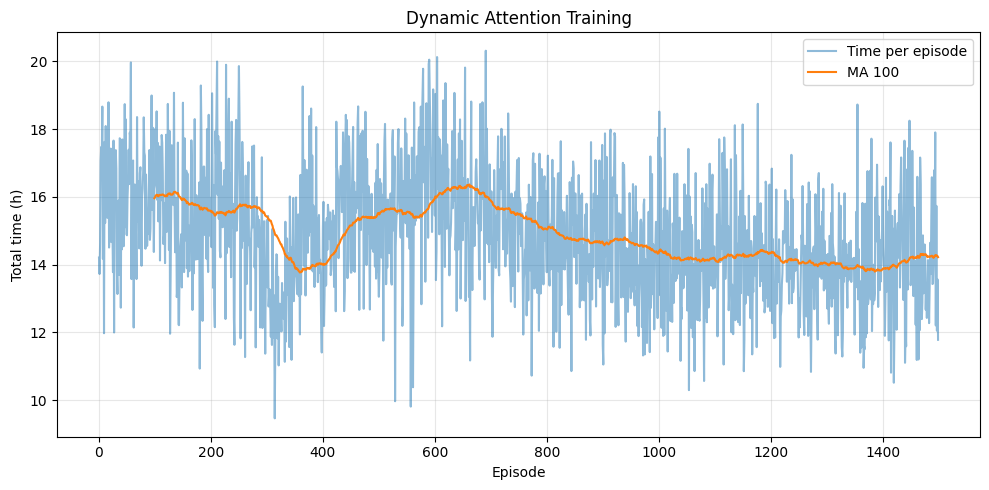

Обученная модель сохранена в dynamic_attention_stepwise.zip


In [ ]:
if __name__ == "__main__":
    train_dynamic_attention(num_episodes=1500)